# Interpretable Learning Energy Model: synthetic workflow

A deterministic companion notebook for the public `prepare -> fit -> inspect -> save/load` workflow. It uses generated data only; it is not a PISA reproduction.

## Goal

Fit a binary pairwise maximum-entropy model, inspect its moments and correlations, compare fitted moments, and verify artifact reload.

## Setup

The random seed, binary encoding, exact computation threshold, and model convention are explicit. The model uses `E=h·s+sum(i<j)J[i,j]s[i]s[j]` and `p(s) ∝ exp(-E)`.

In [1]:
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Make the notebook runnable from the repository checkout without installing first.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "learning_energy_model").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from learning_energy_model import (
    DataConfig,
    LearningModel,
    compare_moment_orders,
    prepare_tabular_data,
)

SEED = 2026
rng = np.random.default_rng(SEED)


## Steps

### 1. Prepare a synthetic table

In [2]:
raw_table = {
    "resource": rng.normal(size=500),
    "support": rng.normal(size=500),
    "engagement": rng.normal(size=500),
}
raw_table["outcome"] = (
    0.9 * raw_table["resource"]
    - 0.5 * raw_table["support"]
    + 0.25 * raw_table["engagement"]
    + rng.normal(size=500)
    > 0
).astype(float)
prepared = prepare_tabular_data(
    raw_table,
    feature_names=("resource", "support", "engagement"),
    target_name="outcome",
)
prepared.X.shape, prepared.y.mean()

((500, 3), np.float64(0.464))

### 2. Fit and inspect the model

In [3]:
config = DataConfig(
    feature_names=prepared.feature_names,
    target_name=prepared.target_name,
    metadata={"source": "synthetic notebook", "seed": SEED},
)
model = LearningModel(config, seed=SEED, max_epochs=500, tolerance=0.03)
fit_result = model.fit(prepared.X, prepared.y)
analysis = model.analyze()
print({
    "converged": fit_result.converged,
    "epochs": fit_result.epochs,
    "calculation": fit_result.diagnostics["calculation"],
    "target_probability": round(float(analysis.means[-1]), 3),
})

{'converged': True, 'epochs': 406, 'calculation': 'exact', 'target_probability': 0.476}


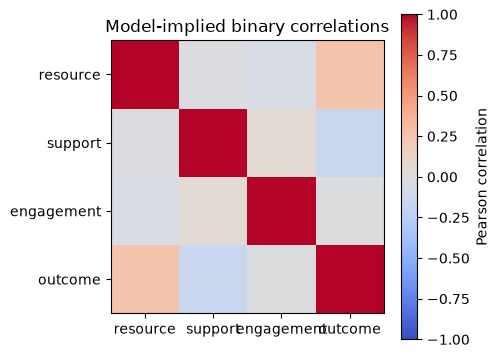

In [4]:
node_names = list(prepared.feature_names) + [prepared.target_name]
fig, axis = plt.subplots(figsize=(5, 4))
image = axis.imshow(analysis.correlations, vmin=-1, vmax=1, cmap="coolwarm")
axis.set(xticks=range(len(node_names)), xticklabels=node_names,
         yticks=range(len(node_names)), yticklabels=node_names,
         title="Model-implied binary correlations")
fig.colorbar(image, ax=axis, label="Pearson correlation")
fig.tight_layout()
plt.show()

### 3. Check moment agreement and reload the artifact

In [5]:
moment_report = compare_moment_orders(
    observed={1: fit_result.observed_means, 2: fit_result.observed_pairwise_moments},
    modeled={1: fit_result.model_means, 2: fit_result.model_pairwise_moments},
    tolerances={1: 0.03, 2: 0.03},
)
assert moment_report.passed
with tempfile.TemporaryDirectory() as directory:
    artifact_path = Path(directory) / "synthetic-model.pt"
    model.save(artifact_path)
    reloaded = LearningModel.load(artifact_path)
    np.testing.assert_allclose(
        model.predict(prepared.X).probabilities,
        reloaded.predict(prepared.X).probabilities,
    )
print(moment_report.to_dict())
print("artifact reload check: passed")

{'max_absolute_error': {'1': 0.015544137164530958, '2': 0.02989913487902185}, 'mean_absolute_error': {'1': 0.007995196406375013, '2': 0.00978042234537482}, 'tolerances': {'1': 0.03, '2': 0.03}, 'passed': True}
artifact reload check: passed


## Checks

The notebook checks convergence, moment tolerances, and prediction equivalence after reload. The displayed correlation matrix is a model association summary, not a causal effect.

## Next Steps

Replace the synthetic table with a locally obtained, codebook-mapped dataset using `PISAMapping` and `prepare_pisa_file`. Keep the raw PISA files outside Git and review weighting, missing-value codes, and sampler diagnostics before interpreting results.